<a href="https://colab.research.google.com/github/AnumahAdeizaStephen/ResNet-Tutorial-/blob/main/2__Network_Training_with%20sharp_22x22%20and%20neighbouring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **STAGE 1: DATA LOADING**

In [1]:
# ============================================================
# ScatterAnalysis — Data processing + model training (Colab)
# Fixes requested (2026-03-12):
#  1) Make GT (22x22) + prediction (22x22) render "sharp" (no blur)
#     - Use interpolation="nearest"
#     - Use exact pixel-center coordinate mapping (extent) and disable resampling
#     - Use aspect="equal"
#     - Optional: show 11x11 sparse GT alongside 22x22 so "upsample blur" isn't mistaken for plotting blur
#
#  2) Write each pixel value on the anode amplitude projection panel
#     - Annotate ALL 11x11 cells, with readable formatting
#     - Automatically choose text color (black/white) based on background
#
# Other retained fixes:
#  - Remove unused create_detector_data()
#  - Fix axis-consistency in _create_target_maps() ([y,x])
#  - Add basic leakage checks (timestamp overlap across splits)
#  - Safer cache naming (avoid collisions)
# ============================================================

# @title a: imports
import os
import re
import gc
import yaml
import pickle
import hashlib
import warnings
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
from tqdm import tqdm

from scipy.special import erf
from scipy.ndimage import zoom

# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.cuda.amp import autocast, GradScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Colab drive
from google.colab import drive

torch.manual_seed(42)
np.random.seed(42)

warnings.filterwarnings("ignore")

drive.mount("/content/drive")

DATA_PATH = "drive/MyDrive/ColabNotebooks/ScatterAnalysis/data_32x32"

CONFIG = "/content/config.yaml"
if not os.path.exists(CONFIG):
    raise FileNotFoundError(
        f"Config not found at {CONFIG}. "
        f"Upload/create it in Colab or change CONFIG to the correct path."
    )
CFG = yaml.safe_load(open(CONFIG))

CHECKPOINT_DIR = "drive/MyDrive/ColabNotebooks/ScatterAnalysis/experiment_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Mounted at /content/drive
Using device: cuda


In [2]:
# ============================================================
# Helpers
# ============================================================
def calculate_pulse_time_simple(w, threshold_ratio=0.5):
    baseline = np.mean(w[:10])
    peak = np.max(w)
    threshold = baseline + threshold_ratio * (peak - baseline)

    above_threshold = w > threshold
    if not np.any(above_threshold):
        return np.nan

    cross_idx = np.argmax(above_threshold)

    if cross_idx > 0:
        t0 = cross_idx - 1
        t1 = cross_idx
        y0 = w[t0] - threshold
        y1 = w[t1] - threshold
        if y0 != y1:
            fractional = -y0 / (y1 - y0)
            return t0 + fractional
    return cross_idx


def _text_color_for_value(v, vmin, vmax, cmap_name="RdBu_r"):
    """
    Pick black/white text for readability by approximating background luminance.
    This avoids hard-to-read annotations.
    """
    try:
        import matplotlib.cm as cm

        cmap = cm.get_cmap(cmap_name)
        if vmax == vmin:
            x = 0.5
        else:
            x = (v - vmin) / (vmax - vmin)
            x = float(np.clip(x, 0.0, 1.0))
        r, g, b, _ = cmap(x)
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        return "black" if luminance > 0.6 else "white"
    except Exception:
        return "black"

In [17]:
# ============================================================
# Data classes
# ============================================================
class RasterScanTorchDataset(Dataset):
    def __init__(self, pixel_tensors, cathode_vectors, positions, transform=None):
        self.pixel_tensors = pixel_tensors
        self.cathode_vectors = cathode_vectors
        self.positions = positions
        self.transform = transform

    def __len__(self):
        return len(self.pixel_tensors)

    def __getitem__(self, idx):
        pixel_tensor = self.pixel_tensors[idx]
        cathode_vector = self.cathode_vectors[idx]
        position = self.positions[idx]

        if self.transform:
            pixel_tensor = self.transform(pixel_tensor)
            cathode_vector = self.transform(cathode_vector)

        return {
            "pixel_tensor": pixel_tensor,
            "cathode_vector": cathode_vector,
            "position": position,
        }


class RasterScanDataset:
    """
    Conventions:
      - pixel_tensors: [y, x, t]
      - maps: [y, x]
    """

    def __init__(
        self,
        bin_file_path,
        config_path=CONFIG,
        grid_size=(11, 11),
        target_type="amplitude",
        filter_empty=True,
        max_samples=None,
    ):
        self.bin_file_path = bin_file_path
        self.config = yaml.safe_load(open(config_path))
        self.grid_size = grid_size
        self.target_type = target_type
        self.filter_empty = filter_empty
        self.max_samples = max_samples

        self.raster_positions = []
        self.pixel_tensors = []
        self.cathode_vectors = []
        self.metadata = []
        self.ground_truth_df = None

        self.df = None
        self.waveforms = None
        self.timestamps = None
        self.x_coords = None
        self.y_coords = None
        self.channel_flags = None
        self.event_groups = None

        self.load_binary_data()
        self.organize_by_raster_position()
        self.calculate_ground_truth_parallel()

        print("Creating target maps (22x22)...")
        self.target_maps = self._create_target_maps()

        if self.filter_empty:
            self._filter_empty_samples()

        if self.max_samples is not None and self.max_samples < len(self.pixel_tensors):
            self._limit_samples()

        print("\n=== Coordinate sanity ===")
        print("df x range:", int(self.df["x"].min()), "to", int(self.df["x"].max()))
        print("df y range:", int(self.df["y"].min()), "to", int(self.df["y"].max()))
        print("pixel_tensors shape:", self.pixel_tensors.shape)
        print("target_maps shape:", self.target_maps.shape)

    def _upsample_map(self, sparse_map, target_size=(22, 22)):
        """
        NOTE: This actually *interpolates* values (order=1).
        That is not a plotting blur; it is real smoothing from the upsample itself.

        If you want a perfectly sharp "blocky" upsample (each 11x11 pixel becomes a 2x2 block),
        change order=0 (nearest neighbor). I am NOT changing it by default because it changes
        your training target distribution.

        If you DO want blocky targets, set order=0 below.
        """
        zoom_factors = (
            target_size[0] / sparse_map.shape[0],
            target_size[1] / sparse_map.shape[1],
        )
        upsampled = zoom(sparse_map, zoom_factors, order=0)  # order=0 for blocky
        return upsampled.astype(np.float32)

    def _filter_empty_samples(self):
        print("\n=== Filtering Empty Samples ===")
        original_count = len(self.target_maps)
        valid_indices = [i for i in range(len(self.target_maps)) if np.max(self.target_maps[i]) > 0]
        print(f"Keeping {len(valid_indices)}/{original_count} samples with positive targets")

        self.pixel_tensors = self.pixel_tensors[valid_indices]
        self.cathode_vectors = self.cathode_vectors[valid_indices]
        self.target_maps = self.target_maps[valid_indices]
        self.raster_positions = self.raster_positions[valid_indices]
        self.metadata = [self.metadata[i] for i in valid_indices]

    def _limit_samples(self):
        print(f"\n=== Limiting to {self.max_samples} samples ===")

        event_ids_with_flag3 = set()
        if self.ground_truth_df is not None:
            flag3_events = self.ground_truth_df[self.ground_truth_df["channel_flag"] == 3]
            event_ids_with_flag3 = set(flag3_events["raster_event_id"].unique())
            print(f"Found {len(event_ids_with_flag3)} events with channel flag 3")

        all_indices = list(range(len(self.pixel_tensors)))
        flag3_indices = [i for i in all_indices if i in event_ids_with_flag3]
        other_indices = [i for i in all_indices if i not in event_ids_with_flag3]

        selected_indices = flag3_indices[: self.max_samples]
        if len(selected_indices) < self.max_samples:
            remaining = self.max_samples - len(selected_indices)
            selected_indices.extend(other_indices[:remaining])

        self.pixel_tensors = self.pixel_tensors[selected_indices]
        self.cathode_vectors = self.cathode_vectors[selected_indices]
        self.target_maps = self.target_maps[selected_indices]
        self.raster_positions = self.raster_positions[selected_indices]
        self.metadata = [self.metadata[i] for i in selected_indices]

        print(
            f"Selected {len(selected_indices)} samples "
            f"({min(len(flag3_indices), self.max_samples)} with channel flag 3)"
        )

    def get_data_dict(self):
        return {
            "pixel_tensors": torch.FloatTensor(self.pixel_tensors),
            "cathode_vectors": torch.FloatTensor(self.cathode_vectors)
            if self.cathode_vectors is not None
            else torch.zeros((len(self.pixel_tensors), 160)),
            "target_maps": torch.FloatTensor(self.target_maps),
            "positions": torch.FloatTensor(self.raster_positions)
            if self.raster_positions is not None
            else torch.zeros((len(self.pixel_tensors), 2)),
        }

    def load_binary_data(self):
        filename = self.bin_file_path

        full_path = str(Path(filename).resolve())
        h = hashlib.md5(full_path.encode("utf-8")).hexdigest()[:10]
        outfilename = f"{Path(filename).stem}_{h}.npy"

        if os.path.exists(outfilename):
            print(f"Loading cached data from {outfilename}")
            with open(outfilename, "rb") as f:
                file_size = np.load(f)
                record_size = np.load(f)
                num_records = np.load(f)
                waveforms = np.load(f)
                timestamp = np.load(f)
                x = np.load(f)
                y = np.load(f)
                channel_flag = np.load(f)
        else:
            data_type = np.dtype(
                [
                    ("length", ">u2"),
                    ("log_type", ">u2"),
                    ("packet_count", ">u2"),
                    ("packet_flags", ">u1"),
                    ("system_number", ">u1"),
                    ("timestamp", ">u8"),
                    ("source_id", ">u1"),
                    ("trig_type", ">u1"),
                    ("user_status", ">u2"),
                    ("event_id", ">u4"),
                    ("pps_timestamp", ">u4"),
                    ("channel_flag", ">u1"),
                    ("cell_pointer", ">u1"),
                    ("x_address", ">u1"),
                    ("y_address", ">u1"),
                    ("waveforms", (">H", (160,))),
                ]
            )

            file_size = os.path.getsize(filename)
            record_size = 32 + 160 * 2
            num_records = file_size // record_size
            memmap = np.memmap(filename, dtype=data_type, mode="r", shape=(num_records))

            prev_timestamp = memmap["timestamp"][0]
            overflow_increment = 0
            adjusted_timestamps = np.zeros_like(memmap["timestamp"])
            for i, ts in enumerate(memmap["timestamp"]):
                if ts < prev_timestamp:
                    overflow_increment += prev_timestamp
                adjusted_timestamps[i] = ts + overflow_increment
                prev_timestamp = ts

            waveforms = memmap["waveforms"].byteswap().view(memmap["waveforms"].dtype.newbyteorder())
            timestamp = adjusted_timestamps.byteswap().view(adjusted_timestamps.dtype.newbyteorder())
            x = memmap["x_address"].byteswap().view(memmap["x_address"].dtype.newbyteorder())
            y = memmap["y_address"].byteswap().view(memmap["y_address"].dtype.newbyteorder())
            channel_flag = memmap["channel_flag"].byteswap().view(memmap["channel_flag"].dtype.newbyteorder())

            with open(outfilename, "wb") as f:
                np.save(f, file_size)
                np.save(f, record_size)
                np.save(f, num_records)
                np.save(f, waveforms)
                np.save(f, timestamp)
                np.save(f, x)
                np.save(f, y)
                np.save(f, channel_flag)

        self.waveforms = waveforms
        self.timestamps = timestamp
        self.x_coords = x
        self.y_coords = y
        self.channel_flags = channel_flag

        self.df = pd.DataFrame(
            {
                "timestamp": self.timestamps,
                "x": self.x_coords,
                "y": self.y_coords,
                "channel_flag": self.channel_flags,
            }
        )
        self.event_groups = self.df.groupby("timestamp")

        print(f"Loaded {len(self.waveforms)} waveform records")
        print(f"Found {len(self.event_groups)} unique events")

    def _create_target_maps(self):
        """
        Build 11x11 sparse target map using [y,x] (0-based), then upsample to 22x22.
        IMPORTANT: The binary data coordinates appear to be 1-based (1..11),
        so we convert to 0-based (0..10) to match visualize_raw_sample().
        """
        target_maps = []

        for event_idx in range(len(self.pixel_tensors)):
            sparse_map = np.zeros((11, 11), dtype=np.float32)

            event_gt = self.ground_truth_df[
                (self.ground_truth_df["raster_event_id"] == event_idx)
                & (self.ground_truth_df["pixel_type"] != 0)
            ]

            for _, row in event_gt.iterrows():
                x0 = int(row["x"]) - 1
                y0 = int(row["y"]) - 1

                if 0 <= x0 < 11 and 0 <= y0 < 11:
                    if self.target_type == "amplitude":
                        v = float(row["amplitude"])
                        if v != 0:
                            sparse_map[y0, x0] = v
                    elif self.target_type == "pulse_time":
                        sparse_map[y0, x0] = float(row["pulse_time"])
                    elif self.target_type == "pixel_type":
                        sparse_map[y0, x0] = float(row["pixel_type"])

            upsampled_map = self._upsample_map(sparse_map, target_size=(22, 22))
            target_maps.append(upsampled_map)

        return np.array(target_maps, dtype=np.float32)

    def organize_by_raster_position(self):
        pixel_tensors_list = []
        cathode_vectors_list = []

        for timestamp, group_df in self.event_groups:
            pixel_tensor = np.zeros((self.grid_size[0], self.grid_size[1], 160), dtype=np.float32)

            anodes_df = group_df[group_df["channel_flag"].isin([1, 3])]
            for idx, row in anodes_df.iterrows():
                x_pos = int(row["x"])
                y_pos = int(row["y"])

                if 0 <= x_pos <= 10 and 0 <= y_pos <= 10:
                    w = self.waveforms[idx].astype(np.float32)
                    wcfg = self.config["waveform"]
                    low = np.mean(w[wcfg["anode_low_lim"][0] : wcfg["anode_low_lim"][1]])
                    high = np.mean(w[wcfg["anode_high_lim"][0] : wcfg["anode_high_lim"][1]])
                    amplitude = max(0.0, float(high - low))

                    if np.max(np.abs(w)) > 0 and amplitude > 0:
                        candidate = w * (amplitude / np.max(np.abs(w)))
                        pixel_tensor[y_pos, x_pos, :] += candidate

            cathode_vector = np.zeros(160, dtype=np.float32)
            cathodes_df = group_df[group_df["channel_flag"] == 2]
            if len(cathodes_df) > 0:
                cath_row = cathodes_df.iloc[0]
                waveform_idx = cath_row.name
                cath_w = self.waveforms[waveform_idx].astype(np.float32)
                cath_min, cath_max = np.min(cath_w), np.max(cath_w)
                if cath_max - cath_min > 0:
                    cathode_vector = (cath_w - cath_min) / (cath_max - cath_min)

            pixel_tensor = -pixel_tensor

            raster_x, raster_y = self.extract_raster_position(timestamp, group_df)
            pixel_tensors_list.append(pixel_tensor)
            cathode_vectors_list.append(cathode_vector)
            self.raster_positions.append((raster_x, raster_y))

            self.metadata.append(
                {
                    "timestamp": timestamp,
                    "raster_x": raster_x,
                    "raster_y": raster_y,
                    "num_channel1": int((group_df["channel_flag"] == 1).sum()),
                    "num_channel2": int((group_df["channel_flag"] == 2).sum()),
                    "num_channel3": int((group_df["channel_flag"] == 3).sum()),
                }
            )

        self.pixel_tensors = np.array(pixel_tensors_list, dtype=np.float32)
        self.cathode_vectors = np.array(cathode_vectors_list, dtype=np.float32)
        self.raster_positions = np.array(self.raster_positions, dtype=np.float32)

    def calculate_ground_truth_parallel(self):
        amplitudes = []
        pulse_times = []
        event_indices = []
        pixel_types = []
        raster_event_ids = []
        pixel_coords = []
        channel_flags = []

        for event_idx, (_, group_df) in enumerate(tqdm(self.event_groups, total=len(self.event_groups))):
            for idx, row in group_df.iterrows():
                w = self.waveforms[idx]

                if row.channel_flag in [1, 3]:
                    wcfg = self.config["waveform"]
                    low = np.mean(w[wcfg["anode_low_lim"][0] : wcfg["anode_low_lim"][1]])
                    high = np.mean(w[wcfg["anode_high_lim"][0] : wcfg["anode_high_lim"][1]])
                    amplitude = float(high - low)
                    pulse_time = calculate_pulse_time_simple(w, 0.3)
                    pixel_type = 3 if row.channel_flag == 3 else 1

                elif row.channel_flag == 2:
                    wcfg = self.config["waveform"]
                    low = np.mean(w[wcfg["cathode_low_lim"][0] : wcfg["cathode_low_lim"][1]])
                    high = np.mean(w[wcfg["cathode_high_lim"][0] : wcfg["cathode_high_lim"][1]])
                    amplitude = float(high - low)
                    pulse_time = calculate_pulse_time_simple(w, 0.3)
                    pixel_type = 0
                else:
                    continue

                amplitudes.append(amplitude)
                pulse_times.append(pulse_time)
                event_indices.append(idx)
                pixel_types.append(pixel_type)
                raster_event_ids.append(event_idx)
                pixel_coords.append((int(row.x), int(row.y)))
                channel_flags.append(int(row.channel_flag))

        self.ground_truth_df = pd.DataFrame(
            {
                "original_index": event_indices,
                "amplitude": amplitudes,
                "pulse_time": pulse_times,
                "pixel_type": pixel_types,
                "raster_event_id": raster_event_ids,
                "x": [c[0] for c in pixel_coords],
                "y": [c[1] for c in pixel_coords],
                "channel_flag": channel_flags,
            }
        )

        print("\nChannel flag distribution:")
        print(self.ground_truth_df["channel_flag"].value_counts())

    def extract_raster_position(self, timestamp, group_df):
        filename = Path(self.bin_file_path).stem
        match = re.search(r"x([-\d.]+)_y([-\d.]+)", filename)
        if match:
            return float(match.group(1)), float(match.group(2))
        return 0.0, 0.0

### **STAGE 2: Neural Network**

In [18]:
# ============================================================
# Model
# ============================================================
class ResNetBlock3D(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        downsample_time: bool = False,
        kernel_size: int = 3,
        stride: int = 1,
        activation: str = "leaky_relu",
    ):
        super().__init__()
        self.downsample_time = downsample_time

        self.conv1 = nn.Conv3d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            stride=(1, 1, stride if downsample_time else 1),
        )
        self.bn1 = nn.BatchNorm3d(out_channels)

        self.conv2 = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            stride=1,
        )
        self.bn2 = nn.BatchNorm3d(out_channels)

        if activation == "leaky_relu":
            self.activation = nn.LeakyReLU(negative_slope=0.01, inplace=True)
        elif activation == "relu":
            self.activation = nn.ReLU(inplace=True)
        else:
            self.activation = nn.SiLU(inplace=True)

        self.skip_conv = None
        if in_channels != out_channels or downsample_time:
            self.skip_conv = nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=(1, 1, stride if downsample_time else 1),
            )
            self.skip_bn = nn.BatchNorm3d(out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.activation(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.skip_conv is not None:
            identity = self.skip_conv(identity)
            identity = self.skip_bn(identity)

        out += identity
        out = self.activation(out)
        return out


class ResNetBlock1D(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        downsample: bool = False,
        kernel_size: int = 3,
        stride: int = 1,
        activation: str = "leaky_relu",
    ):
        super().__init__()
        self.downsample = downsample

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            stride=stride if downsample else 1,
        )
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            stride=1,
        )
        self.bn2 = nn.BatchNorm1d(out_channels)

        if activation == "leaky_relu":
            self.activation = nn.LeakyReLU(negative_slope=0.01, inplace=True)
        elif activation == "relu":
            self.activation = nn.ReLU(inplace=True)
        else:
            self.activation = nn.SiLU(inplace=True)

        self.skip_conv = None
        if in_channels != out_channels or downsample:
            self.skip_conv = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride if downsample else 1)
            self.skip_bn = nn.BatchNorm1d(out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.activation(out)
        out = self.conv2(out)
        out = self.bn2(out)

        if self.skip_conv is not None:
            identity = self.skip_conv(identity)
            identity = self.skip_bn(identity)

        out += identity
        out = self.activation(out)
        return out


class RasterScanResNet(nn.Module):
    def __init__(
        self,
        input_shape: Tuple[int, int, int] = (11, 11, 160),
        output_shape: Tuple[int, int] = (22, 22),
        pixel_channels: List[int] = [1, 8, 16, 32],
        cathode_channels: List[int] = [1, 32, 64, 64],
        fusion_channels: int = 64,
        final_channels: List[int] = [64, 32, 16],
        downsample_stages: List[int] = [1, 2, 3],
        dropout_rate: float = 0.1,
        activation: str = "leaky_relu",
        use_baseline_predictor: bool = True,
    ):
        super().__init__()
        self.input_shape = input_shape
        self.output_shape = output_shape
        self.use_baseline_predictor = use_baseline_predictor

        self.pixel_branch = nn.ModuleList()
        self.pixel_initial = nn.Sequential(
            nn.Conv3d(1, pixel_channels[0], kernel_size=3, padding=1),
            nn.BatchNorm3d(pixel_channels[0]),
            nn.LeakyReLU(0.01, inplace=True) if activation == "leaky_relu" else nn.ReLU(inplace=True),
        )
        for i in range(len(pixel_channels) - 1):
            downsample_time = (i + 1) in downsample_stages
            self.pixel_branch.append(
                ResNetBlock3D(pixel_channels[i], pixel_channels[i + 1], downsample_time=downsample_time, activation=activation)
            )

        self.cathode_branch = nn.ModuleList()
        self.cathode_initial = nn.Sequential(
            nn.Conv1d(1, cathode_channels[0], kernel_size=3, padding=1),
            nn.BatchNorm1d(cathode_channels[0]),
            nn.LeakyReLU(0.01, inplace=True) if activation == "leaky_relu" else nn.ReLU(inplace=True),
        )
        for i in range(len(cathode_channels) - 1):
            self.cathode_branch.append(
                ResNetBlock1D(cathode_channels[i], cathode_channels[i + 1], downsample=True, activation=activation)
            )

        self.fusion_projection = nn.Sequential(
            nn.Conv1d(cathode_channels[-1], fusion_channels, kernel_size=1),
            nn.BatchNorm1d(fusion_channels),
            nn.LeakyReLU(0.01, inplace=True) if activation == "leaky_relu" else nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
        )

        self.temporal_collapse = nn.Sequential(
            nn.Conv3d(pixel_channels[-1] * 2, pixel_channels[-1], kernel_size=(1, 1, 3), padding=(0, 0, 1)),
            nn.BatchNorm3d(pixel_channels[-1]),
            nn.LeakyReLU(0.01, inplace=True) if activation == "leaky_relu" else nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((input_shape[0], input_shape[1], 1)),
            nn.Flatten(start_dim=2, end_dim=3),
        )

        # New (2x upsample):
        self.spatial_upsample = nn.ConvTranspose2d(
            in_channels=pixel_channels[-1],
            out_channels=pixel_channels[-1],
            kernel_size=2,
            stride=2,
            padding=0,
            output_padding=0,
            bias=False,
        )

        self.spatial_blocks = nn.ModuleList()
        current_channels = pixel_channels[-1]
        for out_channels in final_channels:
            self.spatial_blocks.append(
                nn.Sequential(
                    nn.Conv2d(current_channels, out_channels, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_channels),
                    nn.LeakyReLU(0.01, inplace=True) if activation == "leaky_relu" else nn.ReLU(inplace=True),
                    nn.Dropout2d(dropout_rate),
                )
            )
            current_channels = out_channels

        self.final_output = nn.Sequential(nn.Conv2d(current_channels, 1, kernel_size=3, padding=1), nn.ReLU())

        if self.use_baseline_predictor:
            self.baseline_predictor = nn.Sequential(
                nn.Conv3d(pixel_channels[-1], 16, kernel_size=1),
                nn.BatchNorm3d(16),
                nn.LeakyReLU(0.01, inplace=True),
                nn.AdaptiveAvgPool3d((input_shape[0], input_shape[1], 1)),
                nn.Flatten(start_dim=2, end_dim=3),
            )
            self.baseline_conv2d = nn.Sequential(
                nn.Conv2d(16, 8, kernel_size=3, padding=1),
                nn.BatchNorm2d(8),
                nn.LeakyReLU(0.01, inplace=True),
                nn.Conv2d(8, 1, kernel_size=1),
                nn.Upsample(size=output_shape, mode="bilinear", align_corners=False),
                nn.Sigmoid(),
            )
            self.input_magnitude_gate = nn.Sequential(
                nn.AdaptiveAvgPool3d(1),
                nn.Flatten(),
                nn.Linear(pixel_channels[-1], 1),
                nn.Sigmoid(),
            )
        else:
            self.baseline_predictor = None
            self.baseline_conv2d = None
            self.input_magnitude_gate = None

        self._initialize_weights()

    def forward(self, pixel_tensor: torch.Tensor, cathode_vector: torch.Tensor) -> torch.Tensor:
        batch_size = pixel_tensor.shape[0]

        x_pixel = pixel_tensor.unsqueeze(1)
        x_pixel = self.pixel_initial(x_pixel)
        for block in self.pixel_branch:
            x_pixel = block(x_pixel)

        x_cathode = cathode_vector.unsqueeze(1)
        x_cathode = self.cathode_initial(x_cathode)
        for block in self.cathode_branch:
            x_cathode = block(x_cathode)

        cathode_features = self.fusion_projection(x_cathode)
        compressed_time = x_pixel.shape[-1]
        cathode_features = F.interpolate(cathode_features, size=compressed_time, mode="linear", align_corners=False)
        cathode_features = cathode_features.unsqueeze(2).unsqueeze(3)
        cathode_features = cathode_features.expand(-1, -1, x_pixel.shape[2], x_pixel.shape[3], -1)

        fused_features = torch.cat([x_pixel, cathode_features], dim=1)

        baseline_map = None
        if self.use_baseline_predictor:
            baseline_features = self.baseline_predictor(x_pixel)
            baseline_map = self.baseline_conv2d(baseline_features)

            input_gate = self.input_magnitude_gate(x_pixel).unsqueeze(-1).unsqueeze(-1)
            baseline_map = baseline_map * input_gate
            baseline_map = torch.where(baseline_map > 0.05, baseline_map, torch.zeros_like(baseline_map))

        spatial_features = self.temporal_collapse(fused_features)
        spatial_features = spatial_features.view(batch_size, -1, self.input_shape[0], self.input_shape[1])

        spatial_features = self.spatial_upsample(spatial_features)
        for block in self.spatial_blocks:
            spatial_features = block(spatial_features)

        prediction_map = self.final_output(spatial_features).squeeze(1)

        if self.use_baseline_predictor and baseline_map is not None:
            prediction_map = prediction_map * baseline_map.squeeze(1)

        return prediction_map

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Conv3d)):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="leaky_relu")
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Keep your final bias trick (ok if you intentionally want low initial outputs)
        if isinstance(self.final_output, nn.Sequential):
            for mm in self.final_output:
                if isinstance(mm, nn.Conv2d) and mm.bias is not None:
                    nn.init.constant_(mm.bias, -2.0)

        # Initialize ConvTranspose2d upsampler stably
        if isinstance(getattr(self, "spatial_upsample", None), nn.ConvTranspose2d):
            nn.init.constant_(self.spatial_upsample.weight, 0.25)

# ============================================================
# Training
# ============================================================
class RasterScanTrainer:
    def __init__(self, model, train_loader, val_loader, device, config):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.config = config

        self.mixed_precision = config.get("mixed_precision", True) and torch.cuda.is_available()

        loss_fn = config.get("loss_function", "mse")
        self.criterion = nn.MSELoss() if loss_fn == "mse" else nn.L1Loss()

        opt = config.get("optimizer", "adam")
        if opt == "adamw":
            self.optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=config.get("learning_rate", 1e-3),
                weight_decay=config.get("weight_decay", 1e-4),
            )
        else:
            self.optimizer = torch.optim.Adam(
                model.parameters(),
                lr=config.get("learning_rate", 1e-3),
                weight_decay=config.get("weight_decay", 1e-4),
            )

        sched = config.get("scheduler", "cosine")
        if sched == "cosine":
            self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                self.optimizer, T_max=config.get("epochs", 20), eta_min=config.get("min_lr", 1e-6)
            )
        elif sched == "plateau":
            self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer,
                mode="min",
                patience=config.get("scheduler_patience", 5),
                factor=config.get("scheduler_factor", 0.5),
            )
        else:
            self.scheduler = None

        self.history = {"train_loss": [], "val_loss": [], "learning_rates": []}
        self.best_val_loss = float("inf")
        self.patience_counter = 0
        self.patience = config.get("early_stopping_patience", 20)
        self.gradient_accumulation_steps = config.get("gradient_accumulation_steps", 1)

        self.scaler = GradScaler() if torch.cuda.is_available() else None

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        num_batches = 0

        self.optimizer.zero_grad()

        for batch_idx, batch in enumerate(tqdm(self.train_loader, desc="Training", leave=False)):
            pixel_tensor = batch["pixel_tensor"].to(self.device)
            cathode_vector = batch["cathode_vector"].to(self.device)
            target_map = batch["target_map"].to(self.device)

            with autocast(enabled=self.mixed_precision):
                pred_map = self.model(pixel_tensor, cathode_vector)
                loss = self.criterion(pred_map, target_map)
                loss = loss / self.gradient_accumulation_steps

            if self.scaler:
                self.scaler.scale(loss).backward()
            else:
                loss.backward()

            if (batch_idx + 1) % self.gradient_accumulation_steps == 0:
                if self.scaler:
                    self.scaler.unscale_(self.optimizer)
                    if self.config.get("gradient_clip", 0) > 0:
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config["gradient_clip"])
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                else:
                    if self.config.get("gradient_clip", 0) > 0:
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config["gradient_clip"])
                    self.optimizer.step()

                self.optimizer.zero_grad()

            total_loss += loss.item() * self.gradient_accumulation_steps
            num_batches += 1

        return total_loss / max(num_batches, 1)

    def validate(self):
        self.model.eval()
        total_loss = 0.0
        num_batches = 0
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc="Validation", leave=False):
                pixel_tensor = batch["pixel_tensor"].to(self.device)
                cathode_vector = batch["cathode_vector"].to(self.device)
                target_map = batch["target_map"].to(self.device)

                pred_map = self.model(pixel_tensor, cathode_vector)
                loss = self.criterion(pred_map, target_map)

                total_loss += loss.item()
                num_batches += 1
        return total_loss / max(num_batches, 1)

    def train(self, num_epochs, checkpoint_dir=CHECKPOINT_DIR):
        print(f"Starting training for {num_epochs} epochs")
        best_path = os.path.join(checkpoint_dir, "best_model.pt")

        for epoch in range(num_epochs):
            train_loss = self.train_epoch()
            val_loss = self.validate()

            if self.scheduler is not None:
                if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    self.scheduler.step(val_loss)
                else:
                    self.scheduler.step()

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["learning_rates"].append(self.optimizer.param_groups[0]["lr"])

            lr = self.optimizer.param_groups[0]["lr"]
            print(
                f"Epoch {epoch+1:04d}/{num_epochs:04d} | "
                f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {lr:.2e}"
            )

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.patience_counter = 0
                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict": self.model.state_dict(),
                        "optimizer_state_dict": self.optimizer.state_dict(),
                        "val_loss": val_loss,
                        "history": self.history,
                    },
                    best_path,
                )
            else:
                self.patience_counter += 1

            if self.patience_counter >= self.patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        print(f"Training completed. Best val loss: {self.best_val_loss:.6f}")
        checkpoint = torch.load(best_path, map_location=self.device)
        self.model.load_state_dict(checkpoint["model_state_dict"])

    def visualize_training(self):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(self.history["train_loss"], label="Train")
        axes[0].plot(self.history["val_loss"], label="Val")
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(self.history["learning_rates"], marker="o", markersize=3)
        axes[1].set_title("Learning rate")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("LR")
        axes[1].set_yscale("log")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

In [19]:
# ============================================================
# Visualization fixes
# ============================================================
def visualize_raw_sample(dataset, sample_idx=0, debug=True):
    """
    Fix #2: Annotate ALL 11x11 pixel values on the anode amplitude projection.
    """
    meta = dataset.metadata[sample_idx]
    pos = dataset.raster_positions[sample_idx]
    timestamp = meta["timestamp"]

    event_df = dataset.df[dataset.df["timestamp"] == timestamp]

    pixel_raw = np.zeros((11, 11, 160), dtype=np.float32)  # [y,x,t]
    cathode_raw = np.zeros(160, dtype=np.float32)

    wcfg = dataset.config["waveform"]

    amplitude_map = np.zeros((11, 11), dtype=np.float32)  # [y,x]

    for idx, row in event_df.iterrows():
        w = dataset.waveforms[idx].astype(np.float32)

        if row["channel_flag"] in [1, 3]:
            x_pos = int(row['x']) - 1
            y_pos = int(row['y']) - 1
            if 0 <= x_pos < 11 and 0 <= y_pos < 11:
                pixel_raw[y_pos, x_pos, :] += w

                low = np.mean(w[wcfg["anode_low_lim"][0] : wcfg["anode_low_lim"][1]])
                high = np.mean(w[wcfg["anode_high_lim"][0] : wcfg["anode_high_lim"][1]])
                amplitude = float(high - low)  # signed
                amplitude_map[y_pos, x_pos] += amplitude

        elif row["channel_flag"] == 2:
            cathode_raw = w

    pixel_std = np.std(pixel_raw, axis=2)
    peak_time = int(np.argmax(np.max(np.abs(pixel_raw), axis=(0, 1))))
    pixel_peak = pixel_raw[:, :, peak_time]

    active_mask = amplitude_map != 0
    n_active = int(np.sum(active_mask))

    cmin, cmax = float(cathode_raw.min()), float(cathode_raw.max())
    baseline = np.mean(pixel_raw[:, :, :10], axis=2, keepdims=True)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(
        f"Sample {sample_idx} — RAW (11x11)\n"
        f"Timestamp: {timestamp} | Raster: ({pos[0]:.1f}, {pos[1]:.1f}) | "
        f'flag1={meta["num_channel1"]}  flag3={meta["num_channel3"]}  flag2={meta["num_channel2"]}',
        fontsize=10,
    )

    origin = "lower"
    extent = [-0.5, 10.5, -0.5, 10.5]
    tick_locs = list(range(0, 11, 2))

    def _apply_grid_axes(ax):
        ax.set_xlim(-0.5, 10.5)
        ax.set_ylim(-0.5, 10.5)
        ax.set_xticks(tick_locs)
        ax.set_yticks(tick_locs)
        ax.set_xlabel("X coordinate")
        ax.set_ylabel("Y coordinate")
        ax.set_xticks(np.arange(-0.5, 11, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 11, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.5, alpha=0.35)

    amp_absmax = float(np.max(np.abs(amplitude_map))) or 1.0
    vmin, vmax = -amp_absmax, amp_absmax

    im0 = axes[0].imshow(
        amplitude_map,
        cmap="RdBu_r",
        origin=origin,
        extent=extent,
        aspect="equal",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )
    axes[0].set_title(
        f"Anode Amplitude Projection (high-low, signed)\n"
        f"range: [{amplitude_map.min():.1f}, {amplitude_map.max():.1f}]  active: {n_active}/121"
    )
    _apply_grid_axes(axes[0])
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # === FIX: annotate EVERY pixel value (like your "good position 1a") ===
    # formatting: show integers if large, else one decimal
    for y in range(11):
        for x in range(11):
            v = float(amplitude_map[y, x])

            # Annotate ONLY non-zero pixels
            if v == 0:
                continue

            if abs(v) >= 100:
                s = f"{v:.0f}"
            else:
                s = f"{v:.0f}"

            color = _text_color_for_value(v, vmin, vmax, cmap_name="RdBu_r")
            axes[0].text(x, y, s, ha="center", va="center", fontsize=6, color=color)

    im1 = axes[1].imshow(
        pixel_std,
        cmap="plasma",
        origin=origin,
        extent=extent,
        aspect="equal",
        interpolation="nearest",
    )
    axes[1].set_title(f"Anode Std Projection\nrange: [{pixel_std.min():.1f}, {pixel_std.max():.1f}]")
    _apply_grid_axes(axes[1])
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    vmax2 = float(np.abs(pixel_peak).max()) or 1.0
    im2 = axes[2].imshow(
        pixel_peak,
        cmap="RdBu_r",
        origin=origin,
        extent=extent,
        aspect="equal",
        interpolation="nearest",
        vmin=-vmax2,
        vmax=vmax2,
    )
    axes[2].set_title(f"Anode Frame @ t={peak_time}\nrange: [{pixel_peak.min():.1f}, {pixel_peak.max():.1f}]")
    _apply_grid_axes(axes[2])
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    t_axis = np.arange(1, 161)
    axes[3].plot(t_axis, cathode_raw, color="steelblue", linewidth=1.0, label="cathode")
    axes[3].axhline(
        baseline.mean(),
        color="tomato",
        linestyle="--",
        linewidth=0.9,
        label=f"baseline={baseline.mean():.1f}",
    )
    axes[3].set_title(f"Cathode Waveform\nrange: [{cmin:.2f}, {cmax:.2f}]  mean={cathode_raw.mean():.2f}")
    axes[3].set_xlabel("Time sample")
    axes[3].set_ylabel("Amplitude")
    axes[3].legend(fontsize=8)
    axes[3].grid(True, alpha=0.3)
    axes[3].set_xlim(1, 160)

    plt.tight_layout()
    plt.show()

    if debug:
        print(f"[Target 22x22] max: {float(dataset.target_maps[sample_idx].max()):.4f}")


def visualize_22x22_gt_and_prediction(dataset, model, sample_idx=0, device=None, show_sparse_11x11=False):
    """
    Fix #1: Make plotting sharp (no display smoothing).
    Important nuance:
      - If your 22x22 was created using linear interpolation (zoom order=1),
        the *data itself* is smooth. Plotting can still be perfectly sharp.

    We enforce:
      - interpolation='nearest'
      - aspect='equal'
      - resample=False (matplotlib)
      - correct extent so pixel centers align with integer grid
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    gt22 = dataset.target_maps[sample_idx]  # (22,22)

    model.eval()
    with torch.no_grad():
        pixel = torch.from_numpy(dataset.pixel_tensors[sample_idx]).float().unsqueeze(0).to(device)
        cath = torch.from_numpy(dataset.cathode_vectors[sample_idx]).float().unsqueeze(0).to(device)
        pred22 = model(pixel, cath).detach().cpu().numpy()[0]

    err = pred22 - gt22

    extent22 = (-0.5, 21.5, -0.5, 21.5)

    if show_sparse_11x11:
        # Optional: show the underlying 11x11 sparse target for "crisp blocks"
        sparse11 = np.zeros((11, 11), dtype=np.float32)
        gt_rows = dataset.ground_truth_df[
            (dataset.ground_truth_df["raster_event_id"] == sample_idx)
            & (dataset.ground_truth_df["pixel_type"] != 0)
        ]
        for _, row in gt_rows.iterrows():
            x_pos = int(row['x']) - 1
            y_pos = int(row['y']) - 1
            if 0 <= x_pos < 11 and 0 <= y_pos < 11:
                sparse11[y, x] = float(row["amplitude"])

        fig, axes = plt.subplots(1, 4, figsize=(18, 4))
        extent11 = (-0.5, 10.5, -0.5, 10.5)

        im_s = axes[0].imshow(
            sparse11,
            origin="lower",
            extent=extent11,
            interpolation="nearest",
            aspect="equal",
            resample=False,
            cmap="viridis",
        )
        axes[0].set_title("Sparse GT (11x11)")
        plt.colorbar(im_s, ax=axes[0], fraction=0.046, pad=0.04)

        ax_gt, ax_pr, ax_er = axes[1], axes[2], axes[3]
    else:
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        ax_gt, ax_pr, ax_er = axes[0], axes[1], axes[2]

    fig.suptitle(f"Sample {sample_idx}: 22x22 GT vs Prediction", fontsize=11)

    im0 = ax_gt.imshow(
        gt22,
        origin="lower",
        extent=extent22,
        interpolation="nearest",
        aspect="equal",
        resample=False,
        cmap="viridis",
    )
    ax_gt.set_title("GT target (22x22) — sharp render")
    ax_gt.set_xlabel("X")
    ax_gt.set_ylabel("Y")
    plt.colorbar(im0, ax=ax_gt, fraction=0.046, pad=0.04)

    im1 = ax_pr.imshow(
        pred22,
        origin="lower",
        extent=extent22,
        interpolation="nearest",
        aspect="equal",
        resample=False,
        cmap="viridis",
    )
    ax_pr.set_title("Prediction (22x22) — sharp render")
    ax_pr.set_xlabel("X")
    ax_pr.set_ylabel("Y")
    plt.colorbar(im1, ax=ax_pr, fraction=0.046, pad=0.04)

    vmax = float(np.max(np.abs(err))) or 1.0
    im2 = ax_er.imshow(
        err,
        origin="lower",
        extent=extent22,
        interpolation="nearest",
        aspect="equal",
        resample=False,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
    )
    ax_er.set_title("Error (pred - gt)")
    ax_er.set_xlabel("X")
    ax_er.set_ylabel("Y")
    plt.colorbar(im2, ax=ax_er, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

In [20]:
# @title i. Config & Data loading
TRAIN_EPOCHS = 10
DATA_SAMPLES_TO_LOAD = 5000
SAMPLES_TO_VISUALIZE = 3

config = {
    'model': {
        'pixel_channels': [1, 8, 16, 32],
        'cathode_channels': [1, 32, 64, 64],
        'fusion_channels': 32,
        'final_channels': [32, 16, 8],
        'downsample_stages': [1, 2],
        'dropout_rate': 0.2,
        'activation': 'leaky_relu',
        'use_baseline_predictor': True,
    },
    'training': {
        'batch_size': 8,
        'epochs': TRAIN_EPOCHS,
        'learning_rate': 5e-4,
        'weight_decay': 1e-5,
        'gradient_clip': 0.5,
        'gradient_accumulation_steps': 1,
        'loss_function': 'mse',
        'optimizer': 'adam',
        'scheduler': 'cosine',
        'min_lr': 1e-6,
        'early_stopping_patience': 8,
        'print_every': 1,
        'max_memory_gb': 1,
        'mixed_precision': True,
    },
}

print("Loading Dataset from BIN file")
print("=" * 50)

bin_list = [
    f'/content/scan_x2.000_y10.000_2026-03-03__18_22_08.bin',
]

dataset = RasterScanDataset(
    bin_file_path=bin_list[0],
    target_type='amplitude',
    filter_empty=True,
    max_samples=DATA_SAMPLES_TO_LOAD,
)
print("GT x range:", dataset.ground_truth_df["x"].min(), "to", dataset.ground_truth_df["x"].max())
print("GT y range:", dataset.ground_truth_df["y"].min(), "to", dataset.ground_truth_df["y"].max())

print("Creating Data Loaders")
print("=" * 50)

data_dict = dataset.get_data_dict()
total_samples = len(dataset.pixel_tensors)

indices = np.arange(total_samples)
np.random.seed(42)
np.random.shuffle(indices)

train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
train_end = int(train_ratio * total_samples)
val_end = train_end + int(val_ratio * total_samples)

train_indices = indices[:train_end][:5000]
val_indices = indices[train_end:val_end][:1000]
test_indices = indices[val_end:][:1000]

print(f"\n=== Data Split ===")
print(f"Train: {len(train_indices)} samples")
print(f"Val: {len(val_indices)} samples")
print(f"Test: {len(test_indices)} samples")


class SubsetDataset(torch.utils.data.Dataset):
    def __init__(self, data_dict, indices):
        self.data = data_dict
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        return {
            'pixel_tensor': self.data['pixel_tensors'][actual_idx],
            'cathode_vector': self.data['cathode_vectors'][actual_idx],
            'target_map': self.data['target_maps'][actual_idx],
            'position': self.data['positions'][actual_idx],
        }


train_dataset = SubsetDataset(data_dict, train_indices)
val_dataset = SubsetDataset(data_dict, val_indices)
test_dataset = SubsetDataset(data_dict, test_indices)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config['training']['batch_size'], shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=config['training']['batch_size'], shuffle=False, num_workers=0)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=config['training']['batch_size'], shuffle=False, num_workers=0)

Loading Dataset from BIN file
Loading cached data from scan_x2.000_y10.000_2026-03-03__18_22_08_63cc76bd4e.npy
Loaded 110913 waveform records
Found 9054 unique events


100%|██████████| 9054/9054 [00:15<00:00, 581.76it/s]



Channel flag distribution:
channel_flag
1    88609
3    13250
2     9054
Name: count, dtype: int64
Creating target maps (22x22)...

=== Filtering Empty Samples ===
Keeping 9053/9054 samples with positive targets

=== Limiting to 5000 samples ===
Found 9054 events with channel flag 3
Selected 5000 samples (5000 with channel flag 3)

=== Coordinate sanity ===
df x range: 1 to 255
df y range: 1 to 255
pixel_tensors shape: (5000, 11, 11, 160)
target_maps shape: (5000, 22, 22)
GT x range: 1 to 255
GT y range: 1 to 255
Creating Data Loaders

=== Data Split ===
Train: 3500 samples
Val: 750 samples
Test: 750 samples


Initializing Model
Total parameters: 138,239
Trainable parameters: 138,239
Starting Training
Starting training for 10 epochs


Epoch 0001/0010 | Train Loss: 11648.608101 | Val Loss: 8883.177080 | LR: 4.88e-04


Epoch 0002/0010 | Train Loss: 9772.881136 | Val Loss: 8016.502941 | LR: 4.52e-04


Epoch 0003/0010 | Train Loss: 8354.544156 | Val Loss: 7549.301958 | LR: 3.97e-04


Epoch 0004/0010 | Train Loss: 7444.476719 | Val Loss: 6431.846093 | LR: 3.28e-04


...

Epoch 0006/0010 | Train Loss: 6529.182404 | Val Loss: 5811.516029 | LR: 1.73e-04


Epoch 0007/0010 | Train Loss: 6199.967987 | Val Loss: 5207.913888 | LR: 1.04e-04


Epoch 0008/0010 | Train Loss: 6128.776905 | Val Loss: 5355.584938 | LR: 4.87e-05


Epoch 0009/0010 | Train Loss: 5917.345971 | Val Loss: 4944.334502 | LR: 1.32e-05


Epoch 0010/0010 | Train Loss: 5900.399868 | Val Loss: 5138.555967 | LR: 1.00e-06
Training completed. Best val loss: 4944.334502

Visualizing Training Results


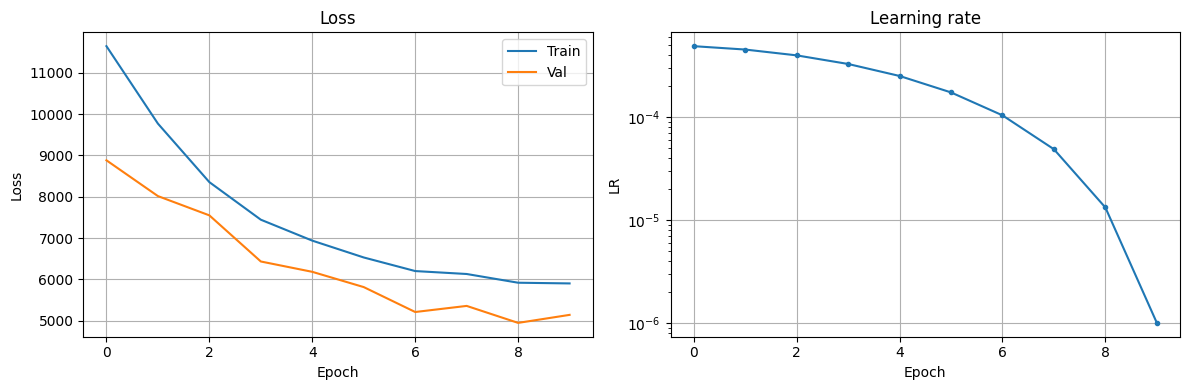

In [21]:
# ============================================================
# ii. Train model
# ============================================================
print("Initializing Model")
print("=" * 50)

model = RasterScanResNet(input_shape=(11, 11, 160), output_shape=(22, 22), **config["model"])

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

trainer = RasterScanTrainer(
    model=model, train_loader=train_loader, val_loader=val_loader, device=device, config=config["training"]
)

print("Starting Training")
print("=" * 50)
trainer.train(num_epochs=config["training"]["epochs"])

print("\nVisualizing Training Results")
print("=" * 50)
trainer.visualize_training()


Visualizing RAW samples (11x11) with per-pixel annotations


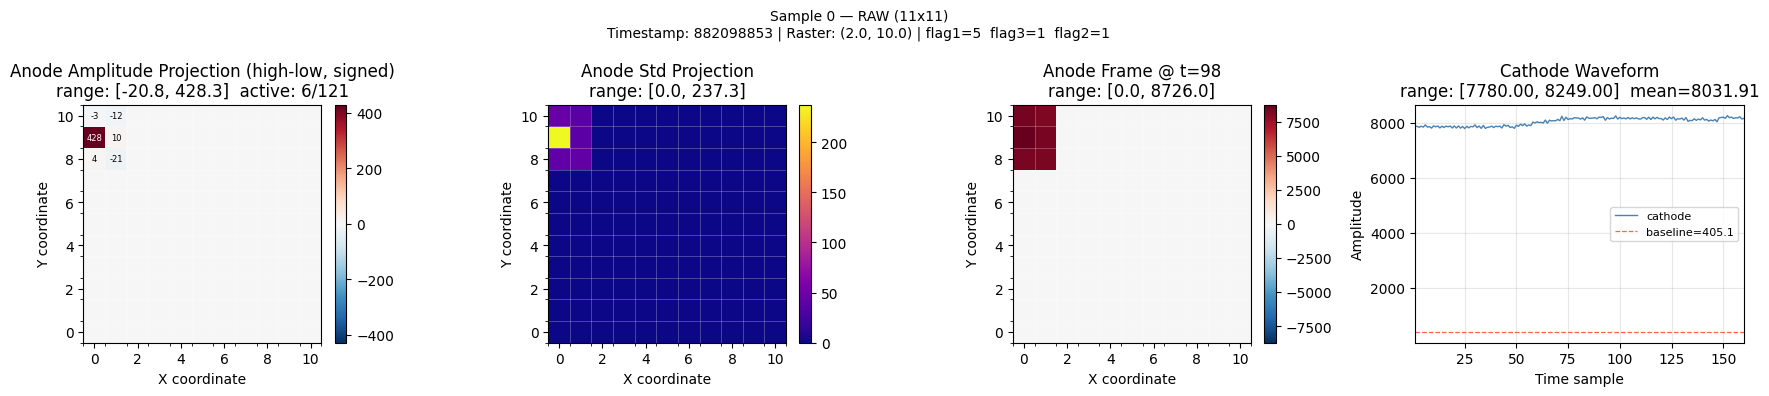

[Target 22x22] max: 428.3219


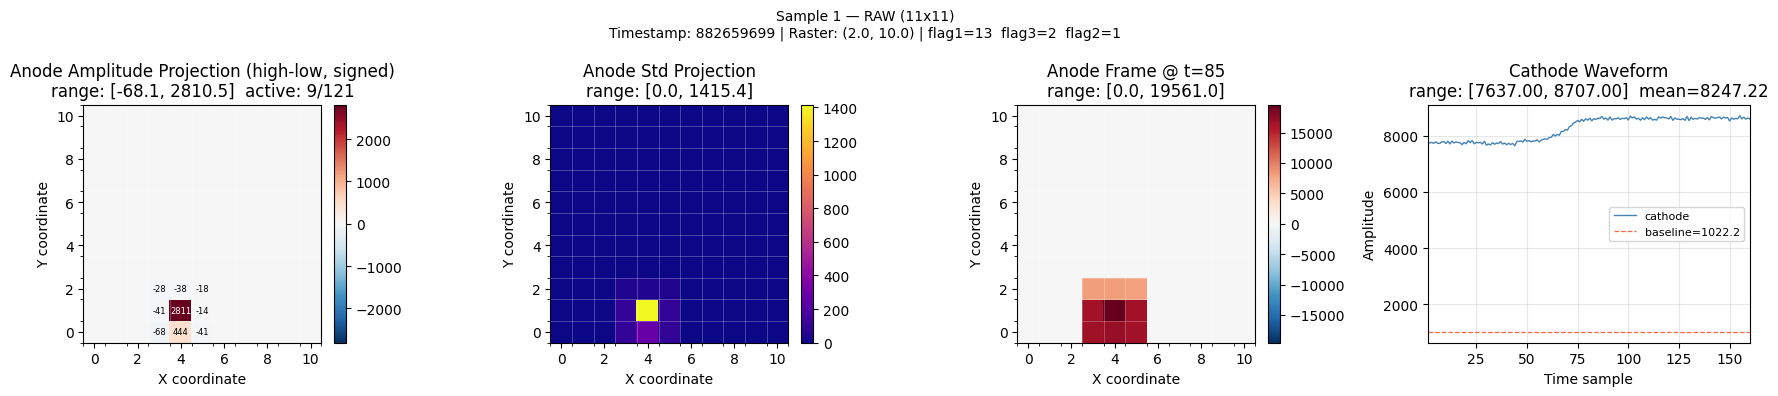

[Target 22x22] max: 1406.4250


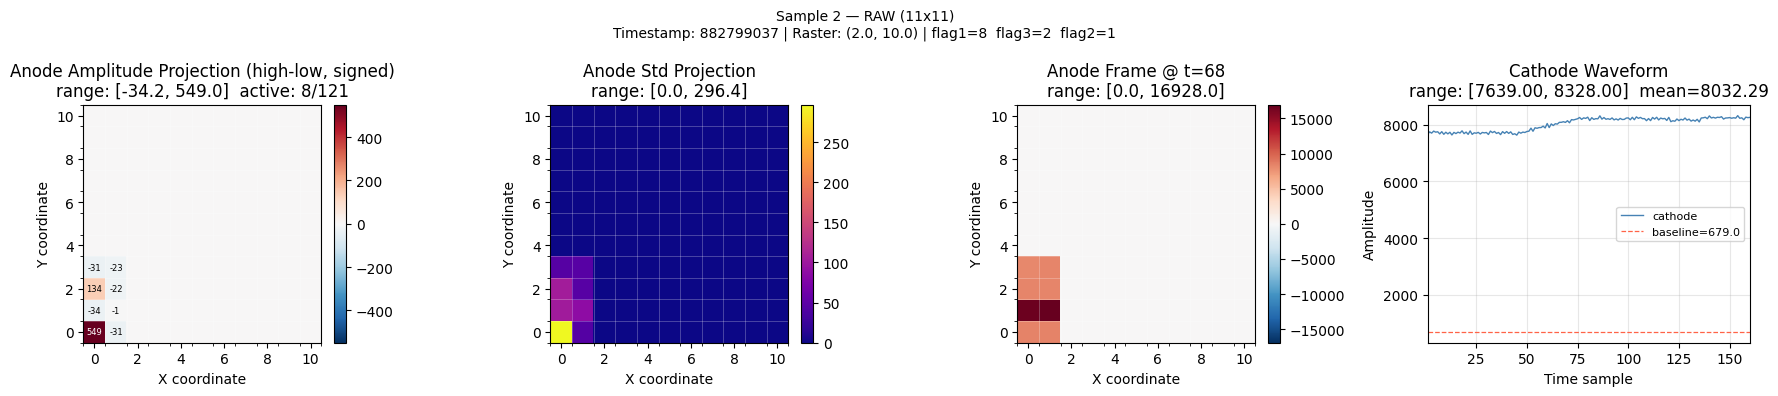

[Target 22x22] max: 548.9554

Visualizing 22x22 target & prediction (sharp render)


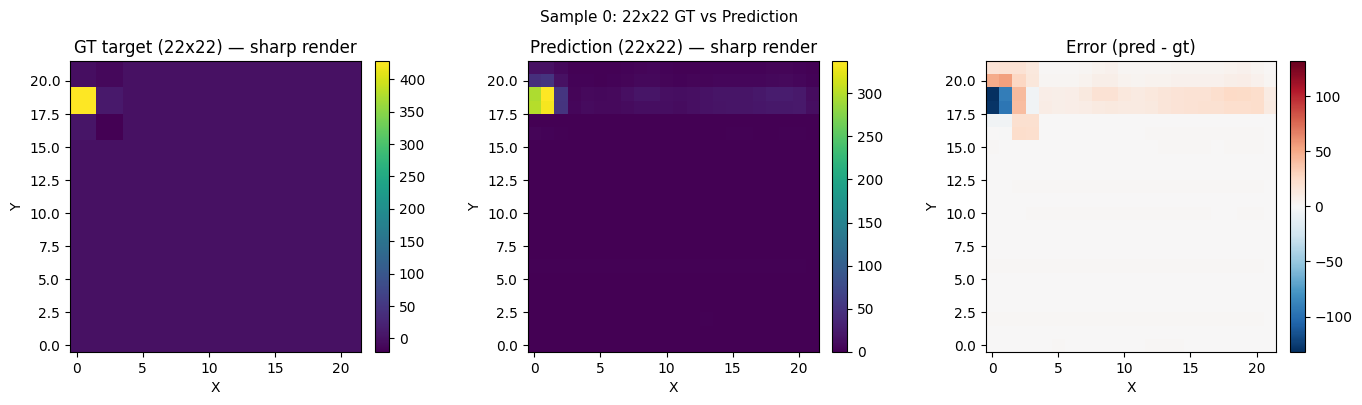

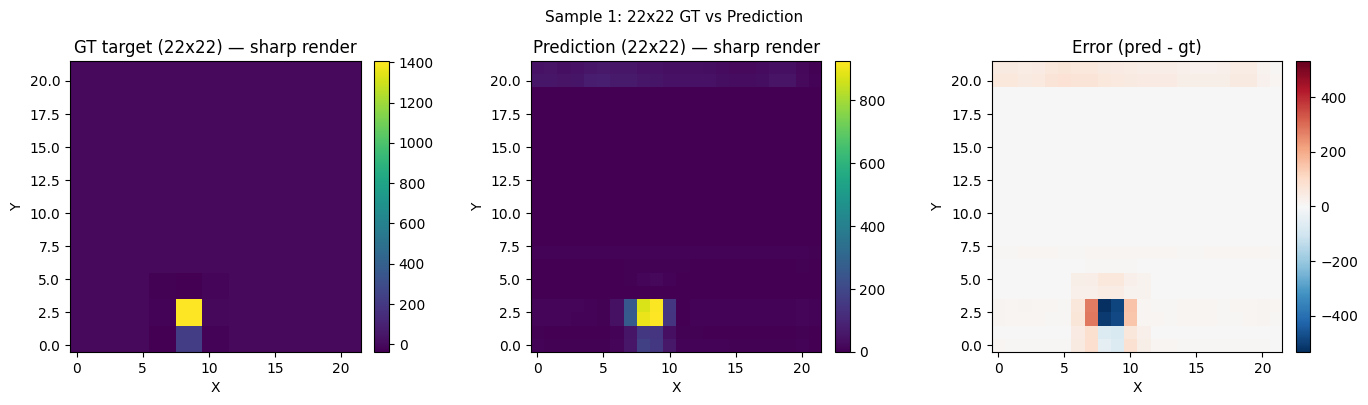

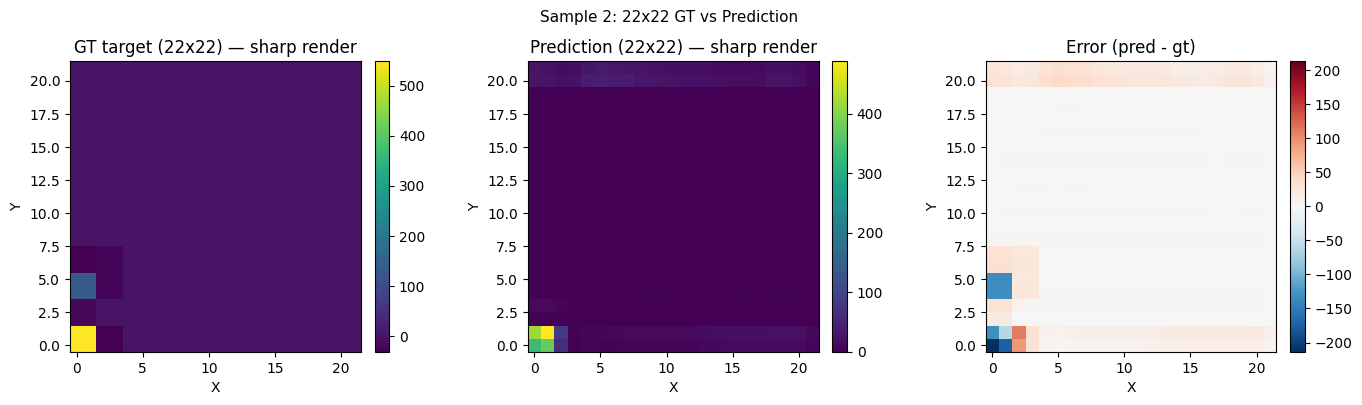

In [22]:
# ============================================================
# iii. Visualize samples
# ============================================================
print("\nVisualizing RAW samples (11x11) with per-pixel annotations")
print("=" * 50)
for idx in range(3):
    visualize_raw_sample(dataset, sample_idx=idx, debug=True)

print("\nVisualizing 22x22 target & prediction (sharp render)")
print("=" * 50)
for idx in range(3):
    # Set show_sparse_11x11=True if you want to compare crisp 11x11 blocks vs interpolated 22x22
    visualize_22x22_gt_and_prediction(dataset, trainer.model, sample_idx=idx, device=device, show_sparse_11x11=False)

Initializing Model
Total parameters: 134,143
Trainable parameters: 134,143
Starting Training
Starting training for 10 epochs
Training samples: 3500
Validation samples: 750


Epoch 0001/0010 | Train Loss: 4797.812018 | Val Loss: 4768.235686 | LR: 4.88e-04 →


Epoch 0002/0010 | Train Loss: 3393.706124 | Val Loss: 3018.667086 | LR: 4.52e-04 ↓


Epoch 0003/0010 | Train Loss: 2476.038042 | Val Loss: 2877.063443 | LR: 3.97e-04 ↓


Epoch 0004/0010 | Train Loss: 1897.475152 | Val Loss: 1440.848257 | LR: 3.28e-04 ↓


...

Epoch 0006/0010 | Train Loss: 1366.811659 | Val Loss: 1387.465992 | LR: 1.73e-04 ↓


Epoch 0007/0010 | Train Loss: 1278.140265 | Val Loss: 689.976604 | LR: 1.04e-04 ↓


Epoch 0008/0010 | Train Loss: 1227.258089 | Val Loss: 1735.541087 | LR: 4.87e-05 ↓


Epoch 0009/0010 | Train Loss: 1216.545235 | Val Loss: 1025.006340 | LR: 1.32e-05 ↓


Epoch 0010/0010 | Train Loss: 1143.175802 | Val Loss: 839.405453 | LR: 1.00e-06 ↓
Training completed. Best validation loss: 689.976604

Visualizing Training Results


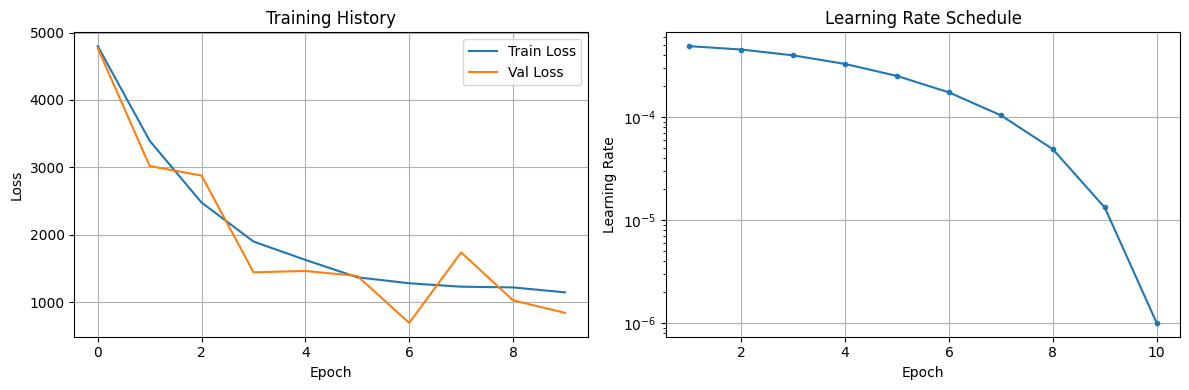

In [20]:
# ============================================================
# ii. Train model
# ============================================================
print("Initializing Model")
print("=" * 50)

model = RasterScanResNet(input_shape=(11, 11, 160), output_shape=(22, 22), **config["model"])

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

trainer = RasterScanTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    config=config["training"],
)

print("Starting Training")
print("=" * 50)
trainer.train(num_epochs=config["training"]["epochs"])

print("\nVisualizing Training Results")
print("=" * 50)
trainer.visualize_training()



Visualizing RAW samples (11x11)


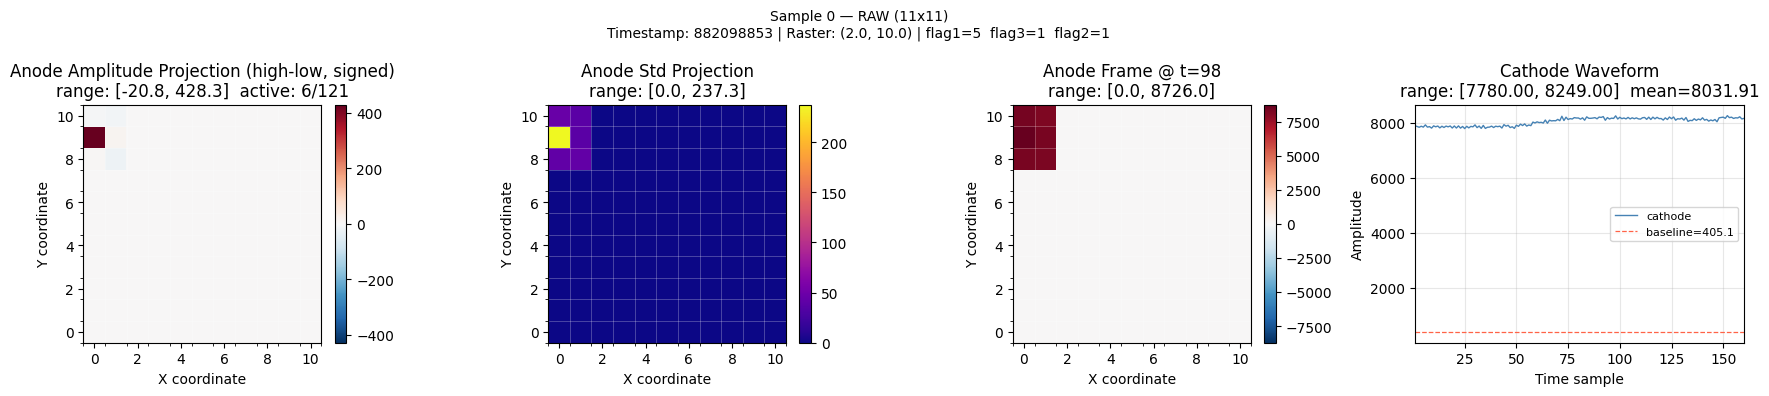


SAMPLE 0 — RAW (11x11)
Timestamp: 882098853 | Raster: (2.00, 10.00)
Channels: flag1=5  flag3=1  flag2=1
[Amplitude map] range: [-20.8, 428.3]
[Target 22x22] max: 407.9256


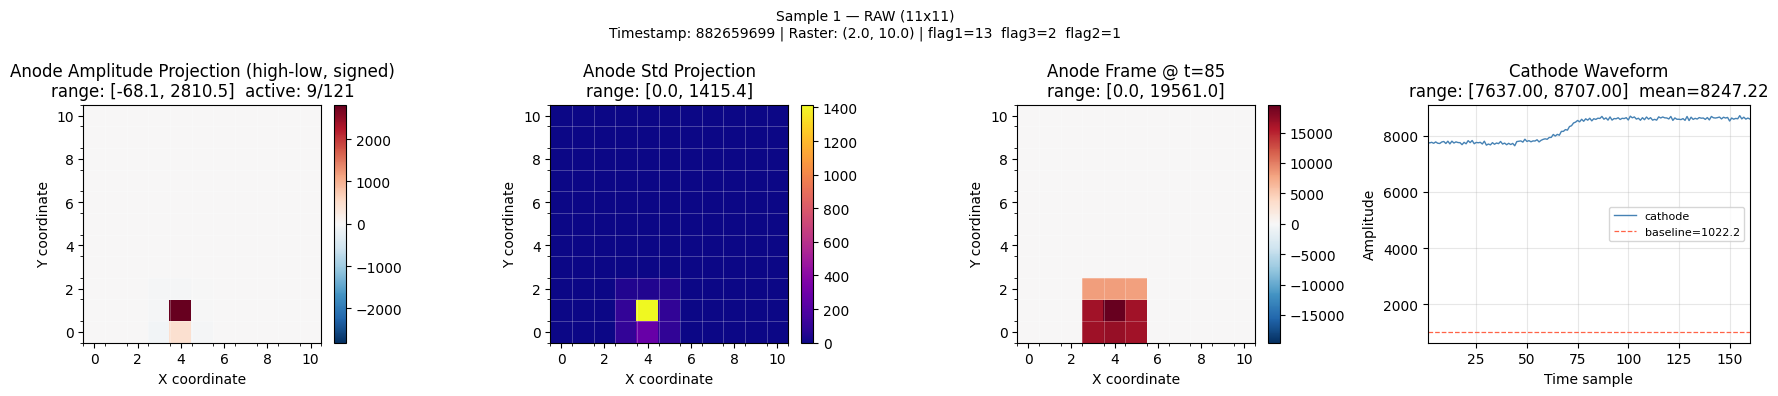


SAMPLE 1 — RAW (11x11)
Timestamp: 882659699 | Raster: (2.00, 10.00)
Channels: flag1=13  flag3=2  flag2=1
[Amplitude map] range: [-68.1, 2810.5]
[Target 22x22] max: 983.6256


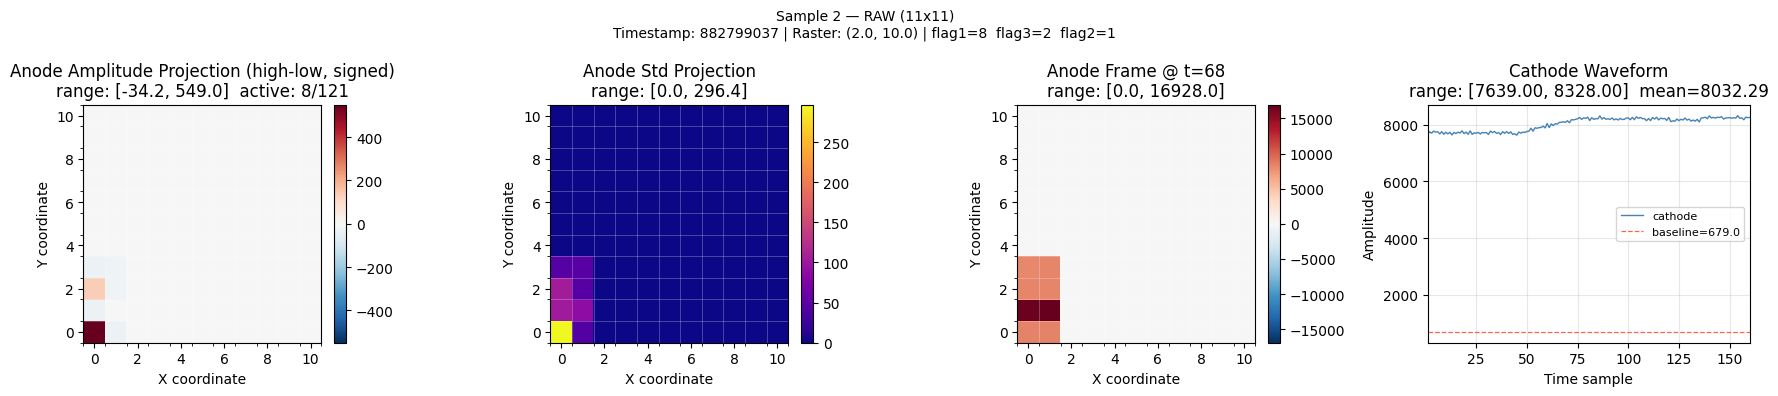


SAMPLE 2 — RAW (11x11)
Timestamp: 882799037 | Raster: (2.00, 10.00)
Channels: flag1=8  flag3=2  flag2=1
[Amplitude map] range: [-34.2, 549.0]
[Target 22x22] max: 497.9188

Visualizing 22x22 target & prediction


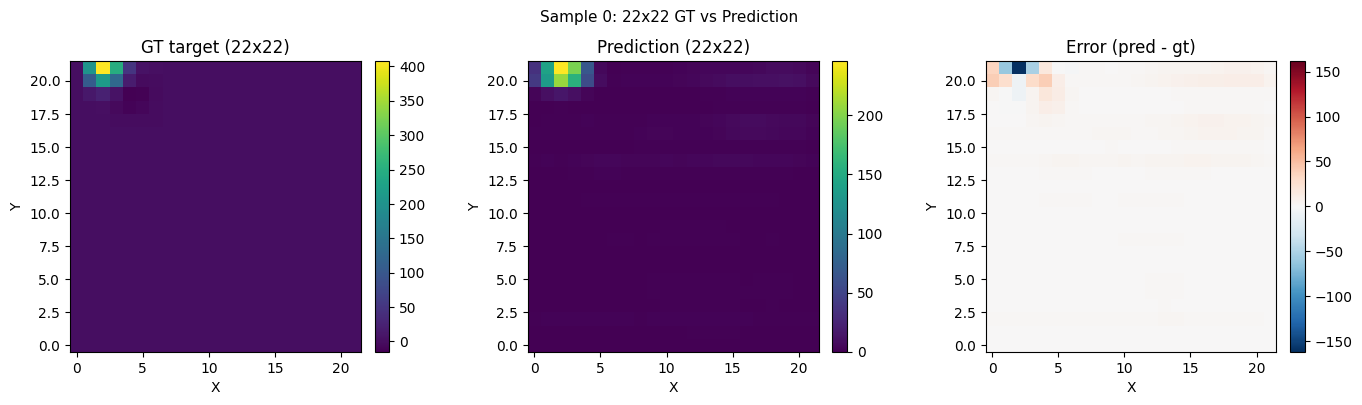

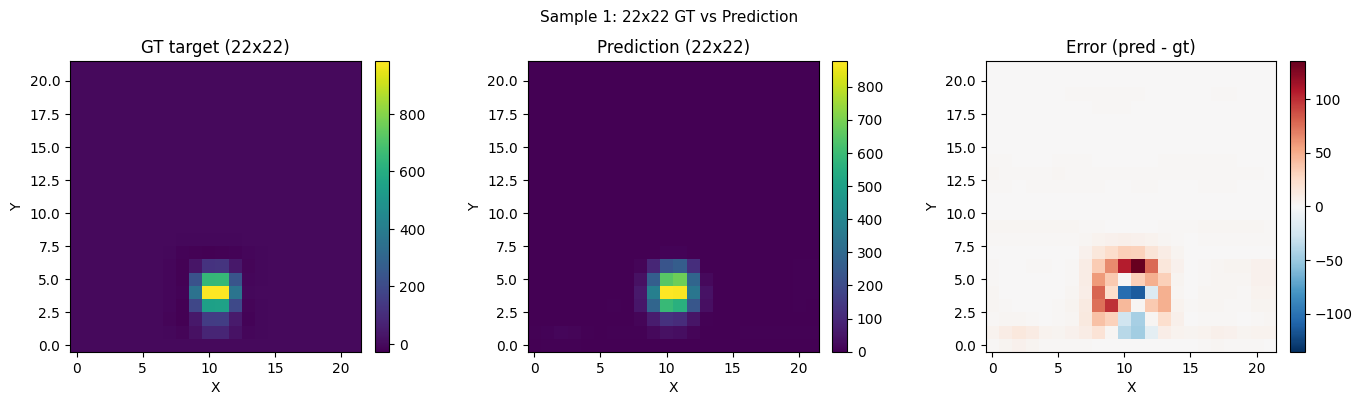

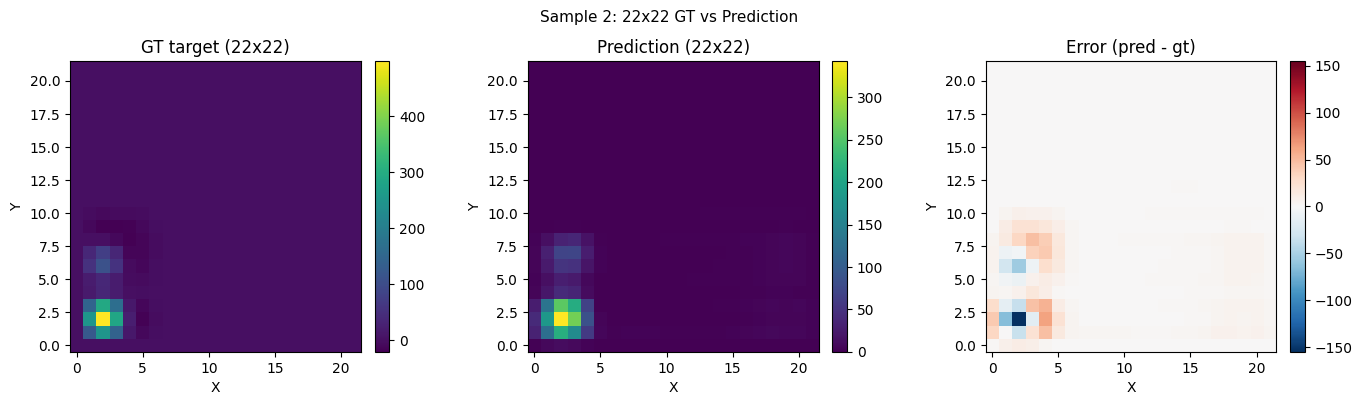

In [21]:
# ============================================================
# iii. Visualize samples (RAW 11x11 + NEW 22x22 GT/pred)
# ============================================================
print("\nVisualizing RAW samples (11x11)")
print("=" * 50)
n_samples = 3
for idx in range(n_samples):
    visualize_raw_sample(dataset, sample_idx=idx, debug=True)

print("\nVisualizing 22x22 target & prediction")
print("=" * 50)
for idx in range(n_samples):
    visualize_22x22_gt_and_prediction(dataset, trainer.model, sample_idx=idx, device=device)

In [2]:
# @title Visualize Exact Event Match

'''
Renders a full 11×12 subplot grid where each cell contains the complete `160-sample waveform for that pixel`. It also:
- Applies curve fitting (stepish_func) to extract pulse times
- Overlays baseline markers (the magenta lines)
- Color-codes by channel flag (green=flag3 main, blue=flag1 neighbor, purple=flag2 cathode)
- Computes and displays Δt between cathode and anode pulse times

It shows the full waveform shape, not just max amplitude.
'''

def visualize_event_exact_match(data_loader, timestamp_index=0):
    timestamps = list(data_loader.event_groups.groups.keys()) #Get the event data
    timestamp = timestamps[timestamp_index]
    event_df = data_loader.event_groups.get_group(timestamp)

    print(f"Visualizing event with timestamp {timestamp}") #Print basic info
    print(f"Event has {len(event_df)} triggered pixels")

    # Create 11x12 grid
    fig, axs = plt.subplots(11, 12, figsize=(20, 10), sharex=True, sharey=True)

    # Hide the extra column subplots like he does
    for row in range(11):
        if row <= 1:
            continue
        axs[row, 11].set_visible(False)

    fig.suptitle(f"Timestamp {timestamp}")

    # Process each pixel
    amplitude_cathode = None
    t_anode = None
    t_cathode = None

    wcfg = data_loader.config['waveform']
    x = np.arange(160)  # Time samples

    for j, (idx, row) in enumerate(event_df.iterrows()): #Loop through each pixel
        w = data_loader.waveforms[event_df.index[j]]

        # EXACT SAME COORDINATE MAPPING
        if 255 in (row.x, row.y):
            ax = axs[0, 11]  # Special position for (255,255) coordinates
        else:
            # This is the key mapping: 11 - y, x - 1
            grid_row = 11 - int(row.y)
            grid_col = int(row.x) - 1
            ax = axs[grid_row, grid_col]

        # Add coordinate label like he does
        ax.text(0.95, 0.05, f"({row.x}, {row.y})", transform=ax.transAxes,
                fontsize=8, verticalalignment="bottom", horizontalalignment="right")

        # Same color scheme
        colors = {
            0: "tab:red",    # Unknown
            1: "tab:blue",   # Neighbour
            2: "tab:purple", # Cathode
            3: "tab:green",  # Anode
        }

        color = colors.get(row.channel_flag, "black")
        ax.plot(w, color, alpha=0.5)

        # Anode processing (channel_flag == 3)
        if row.channel_flag == 3:
            low = np.mean(w[wcfg["anode_low_lim"][0]:wcfg["anode_low_lim"][1]])
            high = np.mean(w[wcfg["anode_high_lim"][0]:wcfg["anode_high_lim"][1]])
            amplitude = high - low

            # Plot the baseline regions like he does
            ax.plot([wcfg["anode_low_lim"][0], wcfg["anode_low_lim"][1]], [low, low], "magenta")
            ax.plot([wcfg["anode_high_lim"][0], wcfg["anode_high_lim"][1]], [high, high], "magenta")

            # Curve fitting like he does
            try:
                popt, _ = curve_fit(stepish_func, x, w,
                                  p0=(np.nanmean(x), np.min(w), np.max(w) - np.min(w), 1.0, 1.0),
                                  maxfev=10000)
                t_anode = popt[0]
                ax.plot(x, stepish_func(x, *popt), 'r-', linewidth=0.5)

                ax.text(0.05, 0.95, f"A={amplitude:.2f}\nt={t_anode:.0f}",
                       transform=ax.transAxes, fontsize=8, verticalalignment="top")
            except:
                ax.text(0.05, 0.95, f"A={amplitude:.2f}",
                       transform=ax.transAxes, fontsize=8, verticalalignment="top")

        # Cathode processing (channel_flag == 2)
        elif row.channel_flag == 2:
            low = np.mean(w[wcfg["cathode_low_lim"][0]:wcfg["cathode_low_lim"][1]])
            high = np.mean(w[wcfg["cathode_high_lim"][0]:wcfg["cathode_high_lim"][1]])

            if amplitude_cathode is not None:
                print("Multiple cathode events in one timestamp")
                continue

            amplitude_cathode = high - low

            # Plot the baseline regions
            ax.plot([wcfg["cathode_low_lim"][0], wcfg["cathode_low_lim"][1]], [low, low], "magenta")
            ax.plot([wcfg["cathode_high_lim"][0], wcfg["cathode_high_lim"][1]], [high, high], "magenta")

            y = w
            popt, pocv = curve_fit(stepish_func, x, y, p0=(np.nanmean(x), np.min(y), np.max(y) - np.min(y), 1.0, 1.0), maxfev=1000000)
            t_cathode = popt[0]
            ax.plot(x, stepish_func(x, *popt), 'r-', linewidth=0.5)

            ax.text(0.05, 0.95, f"A={amplitude_cathode:.2f}\nt={t_cathode:.0f}", transform=ax.transAxes, fontsize=8, verticalalignment="top")

      # If neighbor pixel
        elif row.channel_flag == 1:
            low = np.mean(w[wcfg["anode_low_lim"][0]:wcfg["anode_low_lim"][1]])
            high = np.mean(w[wcfg["anode_high_lim"][0]:wcfg["anode_high_lim"][1]])
            amplitude = high - low

            ax.plot([wcfg["anode_low_lim"][0], wcfg["anode_low_lim"][1]], [low, low], "magenta", alpha=0.5)
            ax.plot([wcfg["anode_high_lim"][0], wcfg["anode_high_lim"][1]], [high, high], "magenta", alpha=0.5)

            # Curve fitting
            try:
                popt, _ = curve_fit(stepish_func, x, w,
                                  p0=(np.nanmean(x), np.min(w), np.max(w) - np.min(w), 1.0, 1.0),
                                  maxfev=10000)
                t_cathode = popt[0]
                ax.plot(x, stepish_func(x, *popt), 'r-', linewidth=0.5)

                ax.text(0.05, 0.95, f"A={amplitude_cathode:.2f}\nt={t_cathode:.0f}",
                       transform=ax.transAxes, fontsize=8, verticalalignment="top")
            except:
                ax.text(0.05, 0.95, f"A={amplitude_cathode:.2f}",
                       transform=ax.transAxes, fontsize=8, verticalalignment="top")

    # Add statistics box like he does
    if t_cathode is not None and t_anode is not None:
        nums = event_df.groupby("channel_flag").size()
        dt = t_cathode - t_anode

        info = "channel_flag amounts\n" + "\n".join([f"{k}: {v}" for k, v in nums.items()])
        info += f"\ndt = {dt:.0f} ns"

        axs[1, 11].text(0.5, 0.5, info, transform=axs[1, 11].transAxes,
                       fontsize=8, verticalalignment="center", horizontalalignment="center")
        axs[1, 11].axis("off")

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

def debug_coordinate_mapping(data_loader, timestamp_index=0):
    """Debug the coordinate mapping to understand the layout"""
    timestamps = list(data_loader.event_groups.groups.keys())
    timestamp = timestamps[timestamp_index]
    event_df = data_loader.event_groups.get_group(timestamp)

    print("Coordinate mapping debug:")
    print("Raw -> Grid mapping: (x, y) -> [11 - y, x - 1]")
    print()

    for idx, row in event_df.iterrows():
        if 255 in (row.x, row.y):
            grid_pos = "(0, 11) - SPECIAL"
        else:
            grid_row = 11 - int(row.y)
            grid_col = int(row.x) - 1
            grid_pos = f"[{grid_row}, {grid_col}]"

        print(f"Raw: ({row.x:3d}, {row.y:3d}) -> Grid: {grid_pos}")

# Debug the mapping first
print("Debugging coordinate mapping...")
debug_coordinate_mapping(dataset, 0)

print("\n" + "="*50)
print("Creating EXACT replica visualizations...")

# Create the exact replicas
for i in range(3):
    visualize_event_exact_match(dataset, i)
    print("-" * 50)

Debugging coordinate mapping...


NameError: name 'dataset' is not defined